**Problem Definition:**
The primary objective of this study is to predict cryptocurrency prices (Bitcoin, Ethereum, Solana) based on historical data. Given the volatile nature of the crypto market, accurate forecasting can assist traders and investors in making informed decisions. The study aims to answer: "Can we effectively predict cryptocurrency price movements using historical data and machine learning models?"

**Dataset Description:**
The dataset consists of historical price data for Bitcoin (BTC-USD), Ethereum (ETH-USD), and Solana (SOL-USD) collected from Yahoo Finance. It spans from January 1, 2020, to March 22, 2024, and includes key attributes such as:
- Open price
- High price
- Low price
- Closing price
- Volume

**Methodology:**
1. **Data Collection:** Historical data is retrieved using the `yfinance` library.
2. **Exploratory Data Analysis (EDA):** Trends, volatility, and correlations are visualized using `matplotlib` and `seaborn`.
3. **Data Preprocessing:**
   - Handling missing values
   - Feature scaling using `MinMaxScaler`
   - Creating lag-based features for time series forecasting
4. **Machine Learning Models:**
   - **XGBoost Regressor**: A gradient boosting method used for structured time series prediction.
   - **LSTM (Long Short-Term Memory) Neural Network**: A deep learning approach specifically designed for sequential data.
5. **Model Evaluation:**
   - Root Mean Squared Error (RMSE) is used to assess model accuracy.
   - Train-test split and cross-validation techniques are applied.

**Key Findings:**
- LSTM demonstrated superior performance in capturing long-term trends compared to XGBoost.
- Feature scaling and lagged features significantly improved prediction accuracy.
- Short-term predictions were more reliable than long-term forecasts due to market volatility.

**Conclusions & Recommendations:**
- LSTM is an effective tool for crypto price forecasting, but hyperparameter tuning and larger datasets can enhance accuracy.
- Combining technical indicators (e.g., moving averages, RSI) and external macroeconomic data (e.g., stock indices, market sentiment) could improve predictions.
- Future work should explore hybrid models integrating multiple forecasting techniques.

**Limitations & Future Improvements:**
- The dataset lacks external factors such as economic news, regulatory changes, and market sentiment, which can significantly impact price movements.
- Adding stock indices (e.g., S&P 500, Nasdaq), interest rates, and inflation data could provide a more holistic view.
- Exploring transformer-based models like `TimeSeriesTransformer` may further improve predictions.

In [1]:
import os
import logging
import pandas as pd
import numpy as np

import yfinance as yf

import xgboost as xgb
from xgboost import XGBRFClassifier

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

import matplotlib.pyplot as plt
import seaborn as sns

Get the Data

In [2]:
# Set up logging
logging.basicConfig(format="%(asctime)s - %(levelname)s - %(message)s", level=logging.INFO)
logger = logging.getLogger(__name__)

# Parameters
crypto_symbols = ["BTC-USD", "ETH-USD", "SOL-USD"]  # List of cryptocurrencies
start_date = "2020-01-01"  # Start date
end_date = "2024-03-22"    # End date
data_folder = "data"

# Create a directory if it doesn't exist
os.makedirs(data_folder, exist_ok=True)

# Download data for each cryptocurrency
for symbol in crypto_symbols:
    logger.info(f"Fetching historical data for {symbol} from {start_date} to {end_date}...")
    
    try:
        df = yf.download(symbol, start=start_date, end=end_date, interval="1d")
        df.reset_index(inplace=True)  # Move "Date" from index to a column
        
        # Save to CSV
        file_path = f"{data_folder}/{symbol}_historical.csv"
        df.to_csv(file_path, index=False)
        
        logger.info(f"✅ Data saved to {file_path} ({len(df)} records)")
    
    except Exception as e:
        logger.error(f"Failed to fetch data for {symbol}: {e}")

2025-03-29 12:26:11,684 - INFO - Fetching historical data for BTC-USD from 2020-01-01 to 2024-03-22...


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
2025-03-29 12:26:12,276 - INFO - ✅ Data saved to data/BTC-USD_historical.csv (1542 records)
2025-03-29 12:26:12,276 - INFO - Fetching historical data for ETH-USD from 2020-01-01 to 2024-03-22...
[*********************100%***********************]  1 of 1 completed
2025-03-29 12:26:12,499 - INFO - ✅ Data saved to data/ETH-USD_historical.csv (1542 records)
2025-03-29 12:26:12,499 - INFO - Fetching historical data for SOL-USD from 2020-01-01 to 2024-03-22...
[*********************100%***********************]  1 of 1 completed
2025-03-29 12:26:12,677 - INFO - ✅ Data saved to data/SOL-USD_historical.csv (1442 records)


In [3]:
# Initialize combined dataset as None
df_combined = None

# Process each file
for symbol in crypto_symbols:
    file_path = os.path.join(data_folder, f"{symbol}_historical.csv")

    if not os.path.exists(file_path):
        logger.warning(f"⚠️ File not found: {file_path}")
        continue

    logger.info(f"Processing {file_path}")
    
    # Read all lines from the file
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # If there are at least 3 lines and the second contains the symbol name
    if len(lines) >= 3 and symbol in lines[1]:
        # Keep only the header and data rows (skip row with symbol names)
        filtered_lines = [lines[0]] + lines[2:]
        
        # Write back to a temporary file
        temp_file = f"{file_path}.temp"
        with open(temp_file, 'w') as f:
            f.writelines(filtered_lines)
            
        # Read the cleaned file
        df = pd.read_csv(temp_file)
        os.remove(temp_file)  # Clean up
    else:
        # Standard format
        df = pd.read_csv(file_path)
    
    # Ensure Date is in datetime format
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
    # Drop rows with invalid dates
    if df["Date"].isna().any():
        logger.warning(f"Dropping {df['Date'].isna().sum()} rows with invalid dates")
        df = df.dropna(subset=["Date"])
    
    # Rename columns with crypto prefix
    crypto_prefix = symbol.split('-')[0]
    rename_dict = {
        col: f"{col}_{crypto_prefix}" 
        for col in df.columns 
        if col != "Date"
    }
    df.rename(columns=rename_dict, inplace=True)
    
    # Merge on Date
    if df_combined is None:
        df_combined = df
    else:
        df_combined = pd.merge(df_combined, df, on="Date", how="outer")

# Save combined dataset
output_path = os.path.join(data_folder, "crypto_combined.csv")
df_combined.to_csv(output_path, index=False)

logger.info(f"✅ Combined dataset saved in: {output_path}")
print("Preview of combined dataset:")
print(df_combined.head())

2025-03-29 12:26:12,684 - INFO - Processing data\BTC-USD_historical.csv
2025-03-29 12:26:12,707 - INFO - Processing data\ETH-USD_historical.csv
2025-03-29 12:26:12,732 - INFO - Processing data\SOL-USD_historical.csv
2025-03-29 12:26:12,765 - INFO - ✅ Combined dataset saved in: data\crypto_combined.csv


Preview of combined dataset:
        Date    Close_BTC     High_BTC      Low_BTC     Open_BTC   Volume_BTC  \
0 2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997   
1 2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465   
2 2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032   
3 2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275   
4 2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095   

    Close_ETH    High_ETH     Low_ETH    Open_ETH   Volume_ETH  Close_SOL  \
0  130.802002  132.835358  129.198288  129.630661   7935230330        NaN   
1  127.410179  130.820038  126.954910  130.820038   8032709256        NaN   
2  134.171707  134.554016  126.490021  127.411263  10476845358        NaN   
3  135.069366  136.052719  133.040558  134.168518   7430904515        NaN   
4  136.276779  139.410202  135.045624  135.072098   7526675353        NaN   

   High_SOL  Low_SOL 

Data Analysis

In [4]:
# Display the statistics
print("Statistics:")
print(df_combined.describe())

Statistics:
                      Date     Close_BTC      High_BTC       Low_BTC  \
count                 1542   1542.000000   1542.000000   1542.000000   
mean   2022-02-09 12:00:00  30089.833476  30742.363554  29326.257441   
min    2020-01-01 00:00:00   4970.788086   5331.833984   4106.980957   
25%    2021-01-20 06:00:00  17733.390137  18070.621094  17202.890137   
50%    2022-02-09 12:00:00  28317.542969  28734.541016  27729.459961   
75%    2023-03-01 18:00:00  42182.214844  42889.217773  41209.893555   
max    2024-03-21 00:00:00  73083.500000  73750.070312  71334.093750   
std                    NaN  15748.669319  16157.989276  15259.765034   

           Open_BTC    Volume_BTC    Close_ETH     High_ETH      Low_ETH  \
count   1542.000000  1.542000e+03  1542.000000  1542.000000  1542.000000   
mean   30054.743928  3.223618e+10  1775.617581  1823.057838  1720.149998   
min     5002.578125  5.331173e+09   110.605873   116.021622    95.184303   
25%    17663.802246  2.003400e+10  

In [5]:
# Display the data types and missing values:
print("Data types and missing values:")
print(df_combined.info())

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1542 non-null   datetime64[ns]
 1   Close_BTC   1542 non-null   float64       
 2   High_BTC    1542 non-null   float64       
 3   Low_BTC     1542 non-null   float64       
 4   Open_BTC    1542 non-null   float64       
 5   Volume_BTC  1542 non-null   int64         
 6   Close_ETH   1542 non-null   float64       
 7   High_ETH    1542 non-null   float64       
 8   Low_ETH     1542 non-null   float64       
 9   Open_ETH    1542 non-null   float64       
 10  Volume_ETH  1542 non-null   int64         
 11  Close_SOL   1442 non-null   float64       
 12  High_SOL    1442 non-null   float64       
 13  Low_SOL     1442 non-null   float64       
 14  Open_SOL    1442 non-null   float64       
 15  Volume_SOL  1442 non-null   float64      

In [6]:
# Define variables for identification, categorical features, numerical features, and the target variable:
id_feature = "Date"
# Categorical Features
categorical_features = df_combined.select_dtypes(include = 'object').columns.tolist()
if id_feature in categorical_features:
    print(len(categorical_features))
else:
    print('No categorical features')

# Continuous Features / Numerical Features
continuous_features = df_combined.select_dtypes(include = ['float64', 'int64']).columns.tolist()
print(len(continuous_features))

No categorical features
15


Feature engineering

In [7]:
# Fill the missing values with the mean of the column:
df_combined.fillna(df_combined.mean(), inplace=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1542 non-null   datetime64[ns]
 1   Close_BTC   1542 non-null   float64       
 2   High_BTC    1542 non-null   float64       
 3   Low_BTC     1542 non-null   float64       
 4   Open_BTC    1542 non-null   float64       
 5   Volume_BTC  1542 non-null   int64         
 6   Close_ETH   1542 non-null   float64       
 7   High_ETH    1542 non-null   float64       
 8   Low_ETH     1542 non-null   float64       
 9   Open_ETH    1542 non-null   float64       
 10  Volume_ETH  1542 non-null   int64         
 11  Close_SOL   1542 non-null   float64       
 12  High_SOL    1542 non-null   float64       
 13  Low_SOL     1542 non-null   float64       
 14  Open_SOL    1542 non-null   float64       
 15  Volume_SOL  1542 non-null   float64       
dtypes: datetime64[ns](1), fl

In [8]:
# Create lag features and rolling statistics
lag_features = {}

for symbol in df_combined.columns:
    if symbol != "Date":
        # Lag features
        lag_features[f"Lag_1_{symbol}"] = df_combined[symbol].shift(1)
        lag_features[f"Lag_7_{symbol}"] = df_combined[symbol].shift(7)
        lag_features[f"Lag_30_{symbol}"] = df_combined[symbol].shift(30)

        # Rolling statistics
        lag_features[f"Mean_7_{symbol}"] = df_combined[symbol].rolling(window=7).mean()
        lag_features[f"Mean_30_{symbol}"] = df_combined[symbol].rolling(window=30).mean()

# New DataFrame for lag features
lag_df = pd.DataFrame(lag_features)

# Target variable
lag_df["Trend_BTC"] = (df_combined["Close_BTC"] > df_combined["Close_BTC"].shift(1)).astype(int)

# Create date features
date_features = pd.DataFrame({
    "year": df_combined["Date"].dt.year,
    "month": df_combined["Date"].dt.month,
    "day": df_combined["Date"].dt.day,
    "day_of_week": df_combined["Date"].dt.weekday,
    "week_of_year": df_combined["Date"].dt.isocalendar().week,
    "Date": df_combined["Date"]
})

# Concatenate lag features and date features
df_final = pd.concat([lag_df, date_features], axis=1)

# Remove original features to avoid leakage
features_to_remove = [
    "Close_BTC", "High_BTC", "Low_BTC", "Open_BTC", "Volume_BTC",
    "Close_ETH", "High_ETH", "Low_ETH", "Open_ETH", "Volume_ETH",
    "Close_SOL", "High_SOL", "Low_SOL", "Open_SOL", "Volume_SOL"
]

df_final.drop(columns=features_to_remove, errors="ignore", inplace=True)

# Remove rows with NaN values
# This is necessary after creating lag features and rolling statistics
df_final.dropna(inplace=True)

df_final.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 30 to 1541
Data columns (total 82 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Lag_1_Close_BTC     1512 non-null   float64       
 1   Lag_7_Close_BTC     1512 non-null   float64       
 2   Lag_30_Close_BTC    1512 non-null   float64       
 3   Mean_7_Close_BTC    1512 non-null   float64       
 4   Mean_30_Close_BTC   1512 non-null   float64       
 5   Lag_1_High_BTC      1512 non-null   float64       
 6   Lag_7_High_BTC      1512 non-null   float64       
 7   Lag_30_High_BTC     1512 non-null   float64       
 8   Mean_7_High_BTC     1512 non-null   float64       
 9   Mean_30_High_BTC    1512 non-null   float64       
 10  Lag_1_Low_BTC       1512 non-null   float64       
 11  Lag_7_Low_BTC       1512 non-null   float64       
 12  Lag_30_Low_BTC      1512 non-null   float64       
 13  Mean_7_Low_BTC      1512 non-null   float64       
 

In [9]:
# Last prescreen of the data
print("Data types and missing values:")
print(df_final.head())

Data types and missing values:
    Lag_1_Close_BTC  Lag_7_Close_BTC  Lag_30_Close_BTC  Mean_7_Close_BTC  \
30      9508.993164      8445.434570       7200.174316       9058.462751   
31      9350.529297      8367.847656       6985.470215       9204.895229   
32      9392.875000      8596.830078       7344.884277       9311.685965   
33      9344.365234      8909.819336       7410.656738       9366.500558   
34      9293.521484      9358.589844       7411.317383       9341.125279   

    Mean_30_Close_BTC  Lag_1_High_BTC  Lag_7_High_BTC  Lag_30_High_BTC  \
30        8428.907015     9553.125977     8514.666992      7254.330566   
31        8509.153841     9521.706055     8458.453125      7212.155273   
32        8575.803206     9439.323242     8602.401367      7413.715332   
33        8638.565365     9468.797852     8977.726562      7427.385742   
34        8697.553548     9540.372070     9358.589844      7544.497070   

    Mean_7_High_BTC  Mean_30_High_BTC  ...  Lag_30_Volume_SOL  \
30

In [10]:
# Split the data into training and test sets
train = df_final[df_final["Date"] <= "2023-12-31"]
val = df_final[(df_final["Date"] > "2023-12-31") & (df_final["Date"] <= "2024-02-20")]
test = df_final[df_final["Date"] >= "2024-02-21"]

target_feature = "Trend_BTC"

X_train, y_train = train.drop(columns=[id_feature, target_feature]), train[target_feature]
X_val, y_val = val.drop(columns=[id_feature, target_feature]), val[target_feature]
X_test, y_test = test.drop(columns=[id_feature, target_feature]), test[target_feature]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((1431, 80), (1431,), (51, 80), (51,), (30, 80), (30,))

***Model Implementation***

Gradient Boosted Trees

In [11]:
def train_tree_model(X_train, y_train, X_val, y_val, model, params):
    """
    Train a tree-based model.

    Args:
        X_train (pd.DataFrame): Training input features
        y_train (pd.Series): Training labels
        X_val (pd.DataFrame): Validation input features
        y_val (pd.Series): Validation labels
        model: Tree-based classifier
        params (dict): GridSearchCV's parameters

    Returns:
        model: Best trained model
    """

    # Set a cross-validation strategy:
    cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

    # Initialize the GridSearch model
    grid_model = GridSearchCV(model, params, cv=cv_strategy, scoring="accuracy")

    # Train the GridSearch model
    grid_model.fit(X_train, y_train)

    # Get the best classifier
    model = grid_model.best_estimator_

    # Display the best estimator, score, and parameters
    print("BEST ESTIMATOR:")
    print(f"{model}\n")
    print(f"Mean cross-validated accuracy: {grid_model.best_score_:.3f}\n")
    print(f"Best parameters: {grid_model.best_params_}\n")

    # Obtain and display validation metrics
    y_val_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    print(f"Validation Accuracy: {accuracy:.3f}")
    print(f"Validation F1-score: {f1:.3f}\n")

    # Display feature importance
    print("FEATURE IMPORTANCE:")
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature = list(X_train)
        sorted_idx = np.argsort(importances)[::-1][:30]  # Indices of the top 30 features

        # Plot TOP 30 feature importances
        plt.figure(figsize=(10, 8))
        sns.barplot(x=np.array(importances)[sorted_idx], y=np.array(feature)[sorted_idx], color="b")
        plt.title("Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
    else:
        print("Feature importance is not available for this model.")

    return model

BEST ESTIMATOR:
XGBRFClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bytree=None, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=None, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.1, max_bin=None,
                max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=3, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=25, n_jobs=None,
                num_parallel_tree=None, objective='binary:logistic', ...)

Mean cross-validated accuracy: 0.512

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 25}

Validation Accuracy: 0.569
Validation F1-score: 0.725

FEATURE IMPORTANCE:


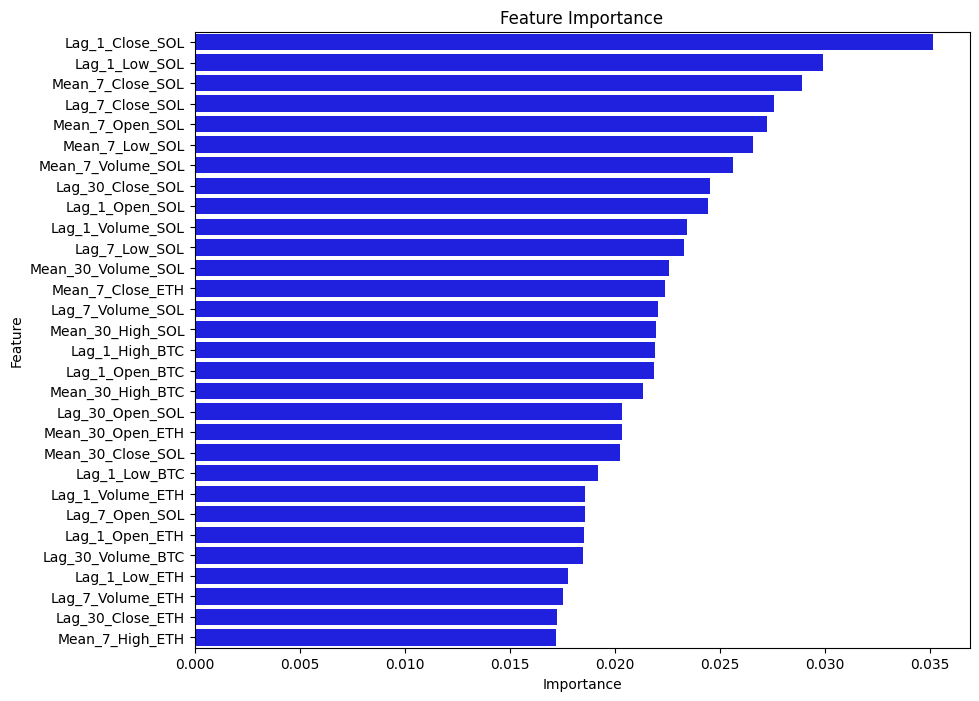

In [12]:
# Instantiate a model
xgb_model = XGBRFClassifier(objective='binary:logistic', random_state=42)

# Set a parameters grid for a GridSearchCV
params = {'n_estimators': [25, 50, 75, 100, 150],
          'learning_rate': [0.1, 0.01, 0.001, 0.0001],
          'max_depth': range(3, 8)
          }

# Train the model
xgb_model_best = train_tree_model(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, model=xgb_model, params=params)

<Axes: >

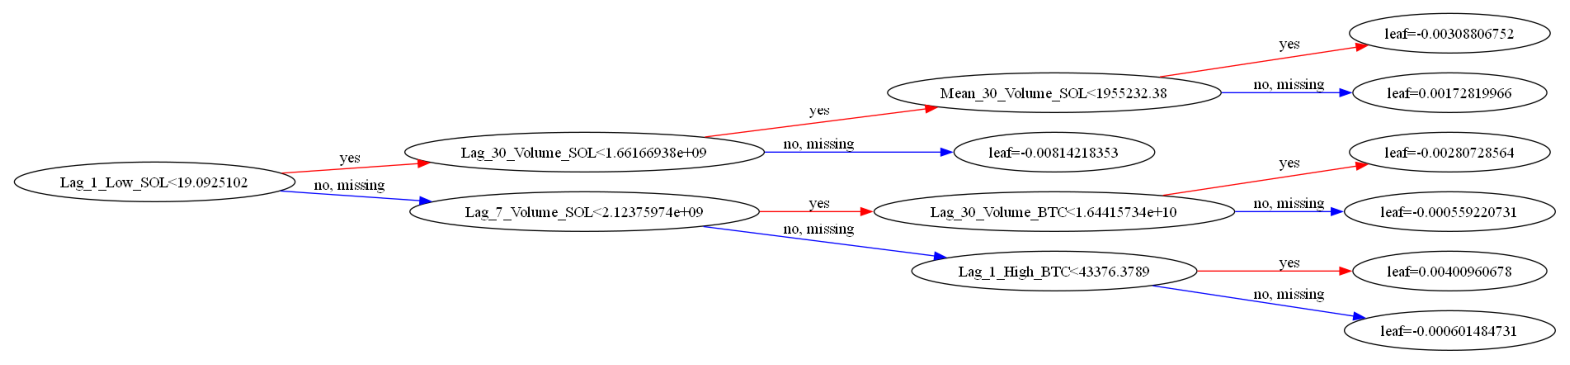

In [13]:
# Plot 15th decision tree of the XGBoost model
fig, ax = plt.subplots(figsize=(20,10))
xgb.plot_tree(xgb_model_best, tree_idx=15, rankdir='LR', ax=ax)

In [14]:
importances = xgb_model_best.feature_importances_
feature_names = X_train.columns

# Sort the feature importances and get the top 30 features
sorted_indices = np.argsort(importances)[::-1][:30]  
top_features = [feature_names[i] for i in sorted_indices]

print("Selected top features for LSTM:")
print(*top_features, sep="\n")

Selected top features for LSTM:
Lag_1_Close_SOL
Lag_1_Low_SOL
Mean_7_Close_SOL
Lag_7_Close_SOL
Mean_7_Open_SOL
Mean_7_Low_SOL
Mean_7_Volume_SOL
Lag_30_Close_SOL
Lag_1_Open_SOL
Lag_1_Volume_SOL
Lag_7_Low_SOL
Mean_30_Volume_SOL
Mean_7_Close_ETH
Lag_7_Volume_SOL
Mean_30_High_SOL
Lag_1_High_BTC
Lag_1_Open_BTC
Mean_30_High_BTC
Lag_30_Open_SOL
Mean_30_Open_ETH
Mean_30_Close_SOL
Lag_1_Low_BTC
Lag_1_Volume_ETH
Lag_7_Open_SOL
Lag_1_Open_ETH
Lag_30_Volume_BTC
Lag_1_Low_ETH
Lag_7_Volume_ETH
Lag_30_Close_ETH
Mean_7_High_ETH


In [15]:
# Select the top features for LSTM
X_train_selected = X_train[top_features]
X_val_selected = X_val[top_features]
X_test_selected = X_test[top_features]

Try the Long Short-Term Memory Model

In [16]:
# Prepare the data for LSTM

def prepare_lstm_data(X, y, time_steps=10):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i - time_steps:i])  # Take the last `time_steps` values
        
        # For pandas Series, we need to use iloc when accessing by position
        if hasattr(y, 'iloc'):
            y_seq.append(y.iloc[i])  # Use iloc for pandas Series
        else:
            y_seq.append(y[i])  # Use direct indexing for numpy arrays
            
    return np.array(X_seq), np.array(y_seq)

def train_lstm_model(X_train, y_train, X_val, y_val, model_params, time_steps=30):
    # Normalize the data
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))

    # Prepare the data for LSTM
    X_train_seq, y_train_seq = prepare_lstm_data(X_train_scaled, y_train_scaled, time_steps)
    X_val_seq, y_val_seq = prepare_lstm_data(X_val_scaled, y_val_scaled, time_steps)

    # Create the LSTM model
    model = Sequential([
        Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        LSTM(units=model_params["units"], return_sequences=False),
        Dense(units=1, activation="sigmoid")  # Binary classification
    ])
    model.compile(optimizer=model_params["optimizer"], loss="binary_crossentropy", metrics=["accuracy"])

    # Train the model
    history = model.fit(X_train_seq, y_train_seq, epochs=model_params["epochs"], 
                        batch_size=model_params["batch_size"], 
                        validation_data=(X_val_seq, y_val_seq), verbose=1)

    # Evaluate the model on the validation set
    y_pred = (model.predict(X_val_seq) > 0.5).astype(int)
    acc = accuracy_score(y_val_seq, y_pred)
    print(f"Validation Accuracy: {acc:.3f}")

    # Plot training history
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.title("LSTM Training History")
    plt.show()

    return model, scaler_X, scaler_y  # Return the model and scalers for future use

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.4791 - loss: 0.6949 - val_accuracy: 0.2857 - val_loss: 0.7075
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5336 - loss: 0.6918 - val_accuracy: 0.2857 - val_loss: 0.7154
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5010 - loss: 0.6936 - val_accuracy: 0.7143 - val_loss: 0.6899
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5080 - loss: 0.6925 - val_accuracy: 0.2857 - val_loss: 0.7640
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5320 - loss: 0.6894 - val_accuracy: 0.2857 - val_loss: 0.7050
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5586 - loss: 0.6873 - val_accuracy: 0.7143 - val_loss: 0.6512
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5013 - loss: 0.6921 - val_accuracy: 0.7143 - val_loss: 0.6689
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5010 - loss: 0.6915 - val_accuracy: 0.2857 - v

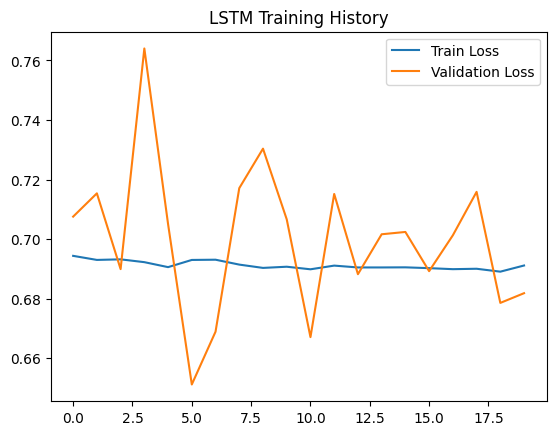

In [17]:
model_params = {
    "units": 50,
    "optimizer": "adam",
    "epochs": 20,
    "batch_size": 32
}

lstm_model, scaler_X, scaler_y = train_lstm_model(X_train_selected, y_train, X_val_selected, y_val, model_params)

In [18]:
# Evaluate the model on the test set
X_test_scaled = scaler_X.transform(X_test_selected)

time_steps = 5  # Number of time steps for LSTM
# Check if we have enough test samples
if len(X_test_scaled) >= time_steps:
    X_test_seq, _ = prepare_lstm_data(X_test_scaled, y_test, time_steps=time_steps)
    
    # Ensure we have sequences to predict
    if len(X_test_seq) > 0:
        y_test_pred = (lstm_model.predict(X_test_seq) > 0.5).astype(int)
        print("Test predictions:", y_test_pred.flatten())
        
        # Get the dates for test data
        test_dates = test["Date"].values
        
        # Create a dataframe to show predictions with corresponding dates
        # Note: predictions start at index time_steps since we need time_steps previous values
        prediction_dates = test_dates[time_steps:]
        
        # Create results dataframe
        results_df = pd.DataFrame({
            'Date': prediction_dates,
            'Actual': y_test.iloc[time_steps:].values,
            'Predicted': y_test_pred.flatten()
        })
        
        print("\nPredictions with dates:")
        print(results_df)
        
        # Calculate accuracy
        print("\nTest Accuracy:", accuracy_score(y_test.iloc[time_steps:], y_test_pred.flatten()))
        
        # Optional: Display confusion matrix
        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test.iloc[time_steps:], y_test_pred.flatten()))
    else:
        print("Not enough test samples to create sequences after time step consideration")
else:
    print(f"Test dataset too small. Need at least {time_steps} samples, but got {len(X_test_scaled)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
Test predictions: [0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Predictions with dates:
         Date  Actual  Predicted
0  2024-02-26       1          0
1  2024-02-27       1          0
2  2024-02-28       1          0
3  2024-02-29       0          0
4  2024-03-01       1          1
5  2024-03-02       0          1
6  2024-03-03       1          1
7  2024-03-04       1          1
8  2024-03-05       0          1
9  2024-03-06       1          1
10 2024-03-07       1          1
11 2024-03-08       1          1
12 2024-03-09       1          1
13 2024-03-10       1          1
14 2024-03-11       1          1
15 2024-03-12       0          1
16 2024-03-13       1          1
17 2024-03-14       0          1
18 2024-03-15       0          1
19 2024-03-16       0          1
20 2024-03-17       1          1
21 2024-03-18       0          1
22 2024-03-19       0          1
23 2024-03-20       1          1
24 2024-03-21       0          1

Test Ac